In [3]:
using Pkg
Pkg.activate(".")
Pkg.add(["Polyhedra", "CDDLib", "Plots", "HiGHS", "NEOSServer", "JuMP"])
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/felipe/trabuco/Polyhedron`
   Resolving package versions...
  No Changes to `~/felipe/trabuco/Polyhedron/Project.toml`
  No Changes to `~/felipe/trabuco/Polyhedron/Manifest.toml`
┌ Warning: Make sure you comply with the NEOS terms of use: http://www.neos-server.org/neos/termofuse.html
└ @ NEOSServer /home/felipe/.julia/packages/NEOSServer/2P7PD/src/NEOSServer.jl:14


In [2]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.8

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

V = [1/4;
     -1/4;]

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

2

declarar as variáveis para o sistema de tanques com atraso d = 2, delta = 0.8

In [ ]:
result_1 = Poly.finding_L_pinvariant_segref_delay_sim2(A_exp, B_exp, E_exp, S, R, V, d, lambda=0.999, lf=24, time=120)

Job 18739785 dispatched
password: KXmezSTQ
---------- Begin Solver Output -----------

Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.



In [113]:
using LinearAlgebra

F = result_1["F"]
F = vcat(F, -F)

48×4 Matrix{Float64}:
 -0.000270066   0.00128233    6.82492e-5   -0.00401255
  0.00195255    0.00261363   -0.000116476   3.5995e-5
  0.00253259    0.00338146   -0.000151214   3.11027e-5
 -0.00156396   -0.0020942     9.28258e-5   -5.24805e-5
  0.004838      0.00641287   -0.000287      0.000109898
  0.014745      0.044121     -0.00144333    7.93906e-5
  0.00182554    0.00244576   -0.000108901   3.49537e-5
 -0.000194381   0.000689181   3.91603e-5   -4.85852e-5
 -0.343071     -0.354656      0.016728      7.86171e-7
  0.000750672   0.000775955   0.00330335    6.5929e-8
  0.000616494   0.000833673  -3.71718e-5    3.16018e-6
  0.00170486    0.00228525   -0.000101738   3.35716e-5
 -0.000490877   0.00349052   -0.000135472  -0.0126655
  ⋮                                        
  0.000490877  -0.00349052    0.000135472   0.0126655
 -1.92913e-5   -2.60028e-5    1.15261e-6   -6.32455e-7
  0.0356648     0.214433     -0.00693639    5.51924e-8
 -4.5069e-5    -6.43757e-5    3.10598e-6    1.50332e-5
 -

In [20]:
G = result_1["G"]

1×4 Matrix{Float64}:
 -1.00055  -1.01744  0.0462952  0.106328

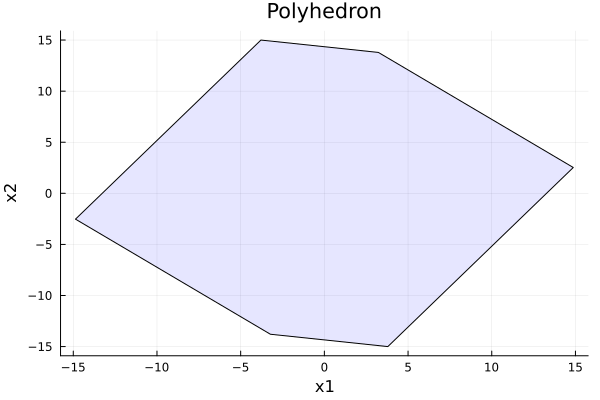

In [114]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

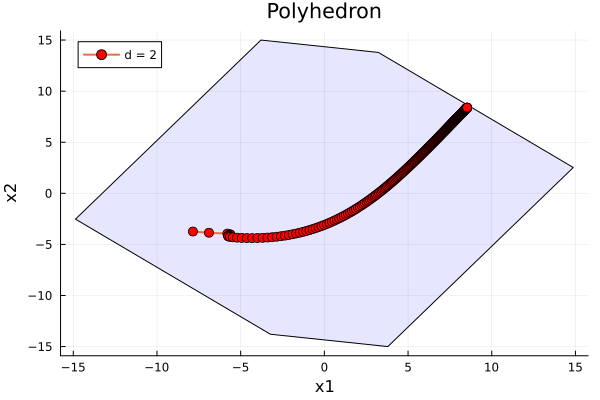

In [117]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 300
r = ones(passos)*8.7 # escolher a referência a se seguir 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj]
x2 = [p[2] for p in traj]
v = [p[3] for p in traj]
w = [p[4] for p in traj]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

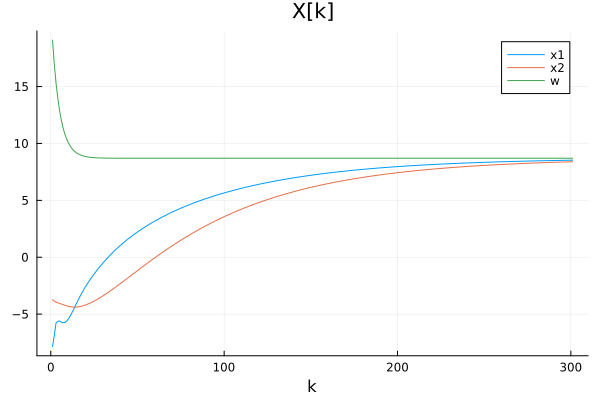

In [118]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

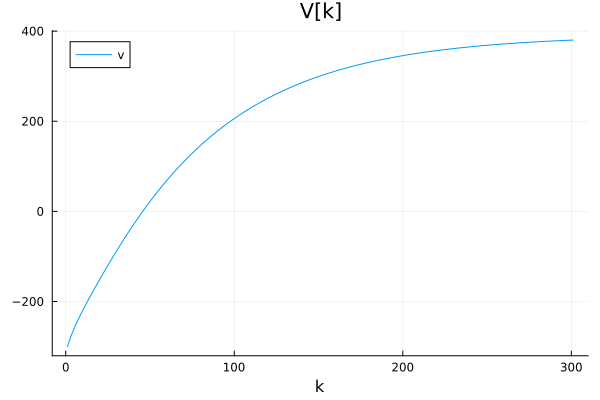

In [119]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

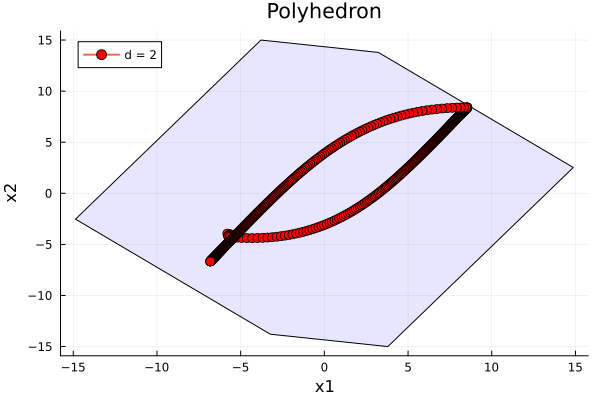

In [120]:
r = ones(passos) * -7

traj2 =Poly.trajectory_segref_delay(traj, A_exp, BG, E_exp, r, passos, d; reverse=false)
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj2]
x2 = [p[2] for p in traj2]
v = [p[3] for p in traj2]
w = [p[4] for p in traj2]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

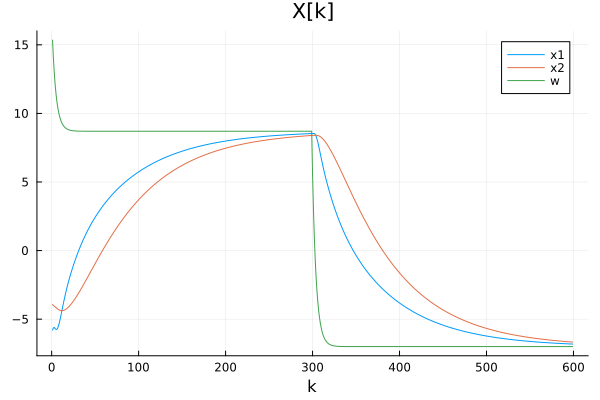

In [121]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

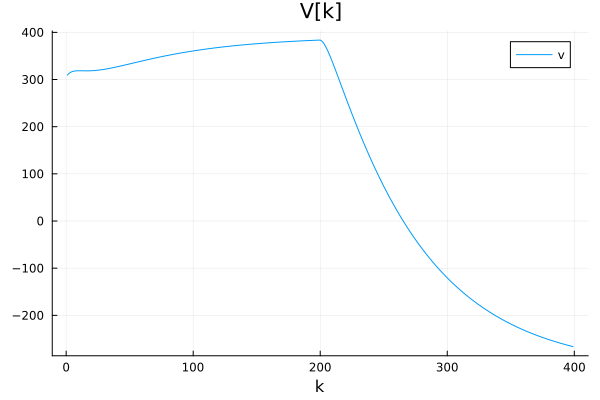

In [56]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")